# **🧠 Introduction: How do diffusion models work?**

Most generative models (like GANs or VAEs) try to generate an image “all at once” from some random vector. Diffusion models do it completely differently – gradually, step by step.

The whole process consists of two main phases: the Forward Process and the Backward Process.

>*Note:* The tutorial is based on the Hugging Face course:
[Diffusion Course](https://huggingface.co/learn/diffusion-course/unit0/1)

## ***1. Forward Process (Adding Noise / Forward Process)***

We take a clean, beautiful image (in our case, a butterfly 🦋) and start adding random noise (Gaussian noise) to it in small increments (steps).

- After 10 steps, the butterfly is a bit noisy.
- After 100 steps, you can barely see the wings.
- After 1000 steps, there is nothing left of the image but pure, random noise (television grain).

*This process is purely mathematical and fixed – we don't need any neural network for it. This planning is handled by a component called* **Scheduler**.

## ***2. Reverse Process (Denoising / Reverse Process)***

**This is where the real magic comes in.** If we could reverse this process – take pure noise and gradually remove noise from it – we could create a completely new image from pure chance!

The problem is that we don’t know exactly how to remove the noise. And that’s why we train a neural network (the **UNet** architecture).

**What exactly does the network learn?** > The network is not tasked with generating a bow tie. It is tasked with looking at a noisy image and **predicting what noise was added to the image at a given step**. When the network correctly estimates this noise, we subtract it from the image. This gives us a slightly cleaner image and we repeat this process a hundred times, perhaps, until we have a perfect bow tie.

## ***3. 🛠️ Building blocks Hugging Face*** `diffusers`

The `diffusers` library from Hugging Face, which we will be working with, breaks this complex system down into several elegant objects:

1. **Models:** Most often a neural network of the `UNet2DModel` type. It has the shape of the letter "U" - first it reduces the image (to understand the global structure), and then it enlarges it again (to calculate the details).
2. **Schedulers:** These control the mathematics behind adding noise during training and subtracting noise during generation.
3. **Pipelines:** A container that connects the model and the planner together so that the end user can simply call `pipe()` and get the finished image.


## ***4. 🎯 Our plan for this tutorial***

In this notebook, we'll first try out the finished image generation pipeline to see how amazing it works. Then we'll break down the training script, where we'll see:

- How to download the butterfly dataset.
- How to set up a scheduler for adding noise.
- How to define a UNet network.
- How to write the training loop itself.

At the end, we will be able to scale this process and share our trained models with the community.

## ***5. How does UNet work in diffusion models?***

In diffusion models, the neural network UNet has a specific task: **it is not tasked with generating a clean image**, but with predicting the noise that was added to the image at a given time step. 

The input to the network is a **noisy image** and information about the **current time step ($t$)**. The output is then an estimated noise map of the same size as the input image. 

The architecture has a characteristic **"U"** shape and consists of three main parts:

1. **Downsampling / Encoder:** Gradually reduces the spatial resolution of the image (e.g. using stepwise convolutions or pooling), but at the same time increases the number of channels (features). In this way, the network captures the global context and coarse features of the image.
2. **Bottleneck:** The lowest layer with the lowest resolution, where the deepest information processing occurs.
3. **Upsampling / Decoder:** Gradually restores the original image resolution (using transposed convolutions or upsampling) and reduces the number of channels.

### ***Key feature: Skip Connections***

Fine spatial details are lost during downscaling in the Encoder. That's why UNet uses **Skip Connections**, which copy detailed features from the Encoder directly to the corresponding layers in the Decoder. This allows the Decoder to perfectly combine global context (from the bottom of the "U") with detailed information (from the side via skip connections).

#### ***UNet Architecture & Diffusion Model Cycle (Graph in Markdown)***




```text
               PREVIOUS PROCESS (Forward Process)
  [ Clear image (x₀) ] --------> Adding noise (Scheduler) --------> [ Pure noise (x_T) ]
                                            |
                                            v
                                 REVERSE PROCESS (Training)
                                            |
  +-----------------------------------------+-----------------------------------------+
  |                                                                                   |
  |      [ Noisy image (x_t) ] + [ Time step (t) ]                                    |
  |                  |                                                                |
  |                  v                                                                |
  |            ============== NETWORK ARCHITECTURE UNet ==============                |
  |            |                                                     |                |
  |   ENCODER  | [Input: 32x32x3]                            [Exit]  |  DECODER       |
  |   (Down)   |     |                                          ^    |    (Up)        |
  |            |     v                                          |    |                |
  |            | [Distinction: 16x16] -- Skip Connection --> [16x16] |                |
  |            |     |                                          ^    |                |
  |            |     v                                          |    |                |
  |            | [Distinction: 8x8]  -- Skip Connection -->  [8x8]   |                |
  |            |     |                                          ^    |                |
  |            +-----+------------------------------------------+----+                |
  |                  |                                          |                     |
  |                  +----------> [ BOTTLENECK: 4x4 ] ----------+                     |
  |                                                                                   |
  |                                         |                                         |
  |                                         v                                         |
  |                             [ Predicted noise (ε_theta) ]                         |
  |                                         |                                         |
  |                                         v                                         |
  |                 Comparison: Calculation of Loss vs. Real Noise                    |
  +-----------------------------------------------------------------------------------+
  ```

#### ***How does this fit into the training cycle?***

1. **Noise sampling:** We take a clean image from our dataset and the scheduler adds random noise to it for a randomly selected time step $t$.
2. **Prediction:** UNet looks at this noisy image and tries to guess what noise has been added.
3. **Optimization:** Using MSE loss (mean square error), we compare the actual added noise with what UNet predicted. The network updates its weights so that it makes fewer errors next time.

During the **generation** (inference) itself, we start with complete noise and let UNet gradually predict and subtract noise in many steps until the final image is created from the "television graininess".

### ***6. 🧠 Grand Synthesis: Three Pillars of Modern Diffusion***

#### ***Pillar 1: Mathematical Core (Noise and Denoising)***

The foundation of everything is the ability to transform chaos into order. This process is driven by two components:

- **Forward Process:** Gradual and controlled destruction of the image by adding Gaussian noise. This step is performed by the **Scheduler** based on mathematical equations.
- **Reverse Process:** Gradual removal of noise step by step. This step cannot be done by mathematics alone - it is performed by a neural network **UNet**, which has been trained to estimate (predict) the exact shape of the added noise at each step.

#### ***Pillar 2: Conditioning (How to drive the model)***

If we let UNet denoise without any guidance, the model would generate a realistic image, but a completely random one every time (so-called *unconditional generation*). In order to generate what we want, we need to **condition** the model (enter the process with additional information):

- **Text conditioning:** A text prompt (e.g. *"Pixar style butterfly"*) is translated into numerical vectors (embeddings) using a text encoder. UNet perceives these vectors and denoises the pixel matrix so that the resulting shapes match the text input.
- **Image conditioning (IP-Adapter, ControlNet):** Instead of text (or next to it), we insert another image as a clue. The model then does not pull random things out of the noise, but copies the identity, pose or composition from our template.

#### ***Pillar 3: Adaptation and Architecture (Fine-tuning and Multi-Agents)***

The final pillar is how we adapt and scale these models for the real world:

- **LoRA and DreamBooth:** Methods that allow us to inject specific new knowledge (your face, your product) into the already finished "brain" of the model with minimal computing power requirements.
- **Mixture of Experts (MoE) & Agents:** The pinnacle of current technology (used in systems like Grok). Instead of a single network, we have a team of specialized experts. In addition, the conversational agent can modify the image iteratively (using Inpainting techniques), thus achieving enormous variability and interactivity.

### ***7. 🗺️ Theoretical Map: From Noise to Ready-Made Agent***

The following diagram shows how the individual layers of technologies theoretically build on each other:

```text
  🏢 APPLICATION LEVEL LAYER (Grok, Multi-Agent Systems, Iterative Editing)
     ▲  - It combines text, multiple image references, and chat for step-by-step editing.
     |
  🎛️ CONTROL & ADAPTATION LAYER (LoRA, DreamBooth, ControlNet, IP-Adapter)
     ▲  - It bends and controls the model to generate specific people, styles, and precise poses.
     |
  🧠 CONDITIONING LAYER (Text-to-Image / CLIP Embeddings)
     ▲  - It translates human input (text/images) into a language that the neural network understands.
     |
  🧱 MATHEMATICAL BASIS (What is explained now: UNet + Scheduler + Differential Noise)
        - A core that can take graininess (noise) and create clean pixels from it step by step.
```

#### ***Conclusion of the theoretical introduction***

In order to effectively work with the upper layers (creating custom agents, training LoRA adapters, or bending ControlNets), one must safely master the lowest layer – the **Mathematical Foundation**. One must understand how the tensor with noise passes through the **UNet** down to the bottleneck and back up again.

# ***Initial setup***

In [1]:
%pip install -qq -U diffusers datasets transformers accelerate ftfy pyarrow
%pip install graphviz
%pip install torchview

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 53.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 92.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.3 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 require

In [2]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
secret_value_1 = user_secrets.get_secret("user_email")
secret_value_2 = user_secrets.get_secret("user_name")
secret_value_3 = user_secrets.get_secret("WAB_LOGIN")

In [3]:
from huggingface_hub import login, HfApi, snapshot_download

if secret_value_0:
    login(token=secret_value_0, add_to_git_credential=False)
    print("✅ Hugging Face login successful.")
else:
    print("❌ Error: Token 'HF_TOKEN' not found in Colab Secrets!")

✅ Hugging Face login successful.


In [4]:
import os, glob
import subprocess

def set_git_config(email, name):
    try:
        # Setting global user.email
        subprocess.run(["git", "config", "--global", "user.email", email], check=True)
        #print(f"Git user.email set to: {email}")

        # Setting the global user.name
        subprocess.run(["git", "config", "--global", "user.name", name], check=True)
        #print(f"Git user.name set to: {name}")

        # Check settings (optional)
        email_output = subprocess.run(["git", "config", "--global", "user.email"], capture_output=True, text=True, check=True)
        name_output = subprocess.run(["git", "config", "--global", "user.name"], capture_output=True, text=True, check=True)
        #print(f"Check - Email: {email_output.stdout.strip()}")
        #print(f"Check - Name: {name_output.stdout.strip()}")

    except subprocess.CalledProcessError as e:
        print(f"Error while setting up Git configuration: {e}")

In [5]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

In [6]:
user_email = secret_value_1
user_name = secret_value_2
#print(user_email, user_name)
set_git_config(user_email, user_name)

Finally, let's import the libraries we'll be using and define a few convenience functions which we'll use later in the notebook:

In [7]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from torchvision import transforms
from diffusers import DDPMPipeline, DDPMScheduler, UNet2DModel
from huggingface_hub import get_full_repo_name, HfApi, create_repo, ModelCard

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [8]:
# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# **🎓 Example 1: First contact with a finished Pipeline (DreamBooth)**

Before we start building our own model from scratch, let's show you what it's like to work with a ready-made, advanced system. This example uses the **[DreamBooth](https://dreambooth.github.io/)** method – a Stable Diffusion model, which the course authors took and specifically trained on just **5 photos** of a children's toy *"Mr Potato Head"*.

#### ***1. Load the generic Pipeline***

The code first imports the necessary `StableDiffusionPipeline` class and downloads the specific weights of the modified model directly from the Hugging Face Hub.

>Note: Because several gigabytes of data are being downloaded, we use the `torch.float16` data type (half precision) in the Google Colab environment, which dramatically saves GPU memory and speeds up the calculation.

In [9]:
from diffusers import StableDiffusionPipeline
import torch

Identifier of the pre-trained model in the DreamBooth library

In [10]:
model_id = "sd-dreambooth-library/mr-potato-head"

Loading the entire pipeline and moving it to the graphics card (device / "cuda")

In [11]:
pipe = StableDiffusionPipeline.from_pretrained(
    model_id, 
    torch_dtype=torch.float16,
    use_safetensors=False
).to("cuda")

model_index.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

#### ***2. Start generation***

Once we have the model's "brain" loaded in memory, we pass it a text prompt and define the sampling parameters:

Definition of a creative prompt with a unique identifier

In [12]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

Generating an image with a defined number of steps and prompt weight

In [13]:
image = pipe(
    prompt, 
    num_inference_steps=50, 
    guidance_scale=7.5
).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

Viewing the resulting image

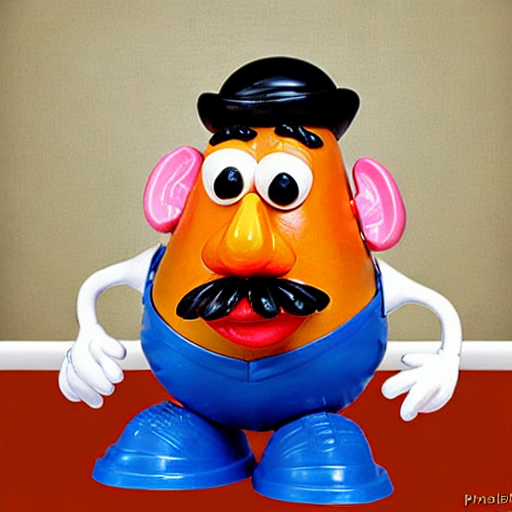

In [14]:
image

#### ***🧪 Laboratory: Exercises and Experiments***

To gain a deeper understanding of what is happening inside this “magic box” (pipeline), the tutorial encourages us to conduct three key experiments:

#### ***Experiment A: What happens if we omit the keyword*** `sks`***?***

- **Theoretical principle:** The DreamBooth method works by assigning a unique, previously unknown token to a new object (this particular toy) in the text dictionary - in this case `sks`.
- **Try changing the prompt to:** `"an abstract oil painting of mr potato head by picasso"` (without `sks`).
- **Expected result:** The model will generate some Mr. Potato because it knows this phrase from its original training on the Internet, but the **unique identity of the specific toy** from those 5 photos will be lost.

  0%|          | 0/50 [00:00<?, ?it/s]

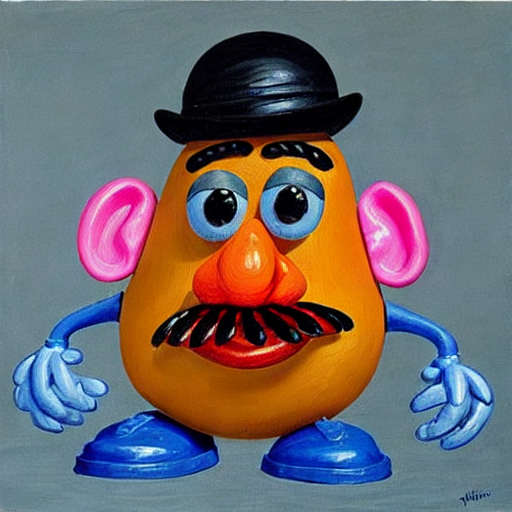

In [15]:
prompt = "an abstract oil painting of mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=50, 
    guidance_scale=7.5
).images[0]

image

#### ***Experiment B: Bending the*** `num_inference_steps parameter`

- **Theoretical principle:** This parameter determines how many times in a row the neural network looks at the noise matrix and subtracts the estimated noise from it (number of denoising steps).
- **Try setting:** `num_inference_steps=10` or even `num_inference_steps=3`.
- **Expected result:** You'll find out how low you can go with the number of steps before the image turns into a blurry digital mush full of artifacts. The diffusion process simply takes time (steps) to extract fine details from the chaos.

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


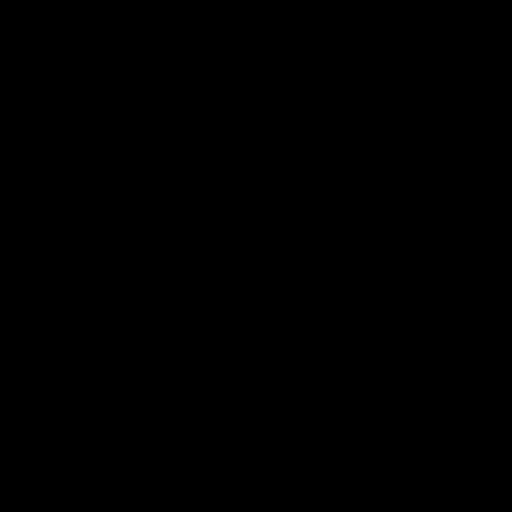

In [16]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=25, 
    guidance_scale=7.5
).images[0]

image

  0%|          | 0/5 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


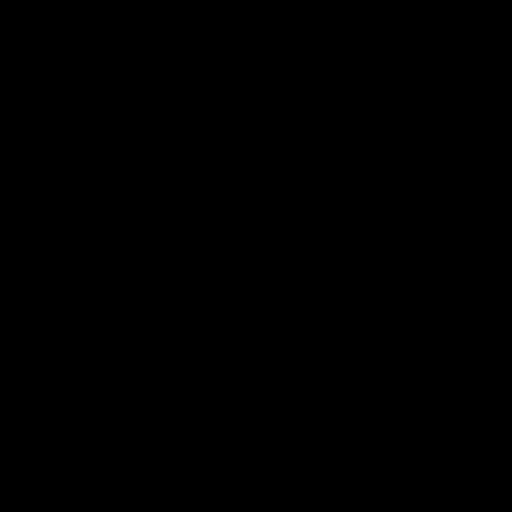

In [17]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=5, 
    guidance_scale=7.5
).images[0]

image

#### ***Experiment C: Playing with the*** `guidance_scale` ***parameter (CFG Scale)***

- **Theoretical principle:** This parameter (Classifier-Free Guidance) tells the model how tightly it should adhere to your textual input at the expense of its own "creative freedom".
- **Standard value:** `7.0` to `9.0` (ideal compromise).
- **Extreme down** (`1.0`–`3.0`): The model almost ignores the prompt, the image will be nice, but it will probably forget about the Picasso style.
- **Extreme Up** (`15.0` and above): The model will try to fulfill the text so literally that the image will start to have unnaturally overblown contrast, distorted colors, and ruined composition.

  0%|          | 0/50 [00:00<?, ?it/s]

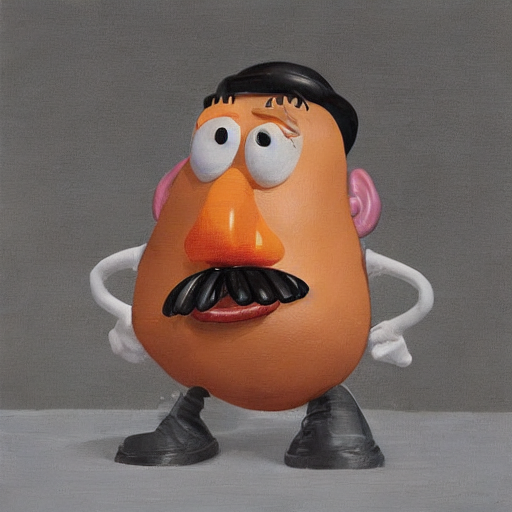

In [18]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=50, 
    guidance_scale=3.0
).images[0]

image

  0%|          | 0/50 [00:00<?, ?it/s]

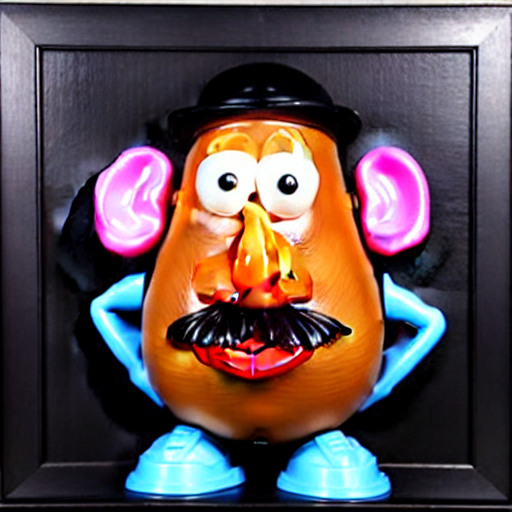

In [19]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=50, 
    guidance_scale=12.0
).images[0]

image

# **🦋 Example 2: Training your own DDPM model from scratch**

In this part of the tutorial, we will go through the complete workflow of training an **unconditional diffusion model** of type DDPM (*Denoising Diffusion Probabilistic Models*). We will train on a small dataset of 1,000 images of butterflies from the Smithsonian Institution, downsized to a resolution of 32×32 pixels so that the training does not take too long.

## ***🗺️ Code structure***

The entire process is divided into 7 logical steps in the code:

1. **Validation of the pre-trained model** (for comparison)
2. **Data preparation and augmentation** (DataLoader)
3. **Definition of Noise Scheduler** (Scheduler)
4. **Network architecture definition** (UNet2DModel)
5. **The training loop itself** (Training Loop in PyTorch)
6. **Sampling and image generation** (Sampling Loop)
7. **Saving and uploading a model** to Hugging Face Hub

## ***💻 Complete monolithic script in Python***

In [20]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from torchvision import transforms
from diffusers import DDPMPipeline, DDPMScheduler, UNet2DModel
from huggingface_hub import get_full_repo_name, HfApi, create_repo, ModelCard

from torchview import draw_graph

#### Auxiliary functions for displaying images (assumed in a laptop environment)

In [21]:
def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im

In [22]:
def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im

----------------------------------------------------------
### ***STEP 1: Quick demo of the finished DDPM model***

----------------------------------------------------------

In [23]:
print("--- Step 1: Loading demo pipeline ---")
butterfly_pipeline = DDPMPipeline.from_pretrained(
    "johnowhitaker/ddpm-butterflies-32px", allow_pickle=False
).to(device)

--- Step 1: Loading demo pipeline ---


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Keyword arguments {'allow_pickle': False} are not expected by DDPMPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--johnowhitaker--ddpm-butterflies-32px/snapshots/ff99059aed185f6158729b8e9f2286c4b9c177f3: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--johnowhitaker--ddpm-butterflies-32px/snapshots/ff99059aed185f6158729b8e9f2286c4b9c177f3.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1000 [00:00<?, ?it/s]

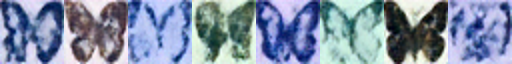

In [24]:
images = butterfly_pipeline(batch_size=8).images
make_grid(images)  # Displays a grid of butterflies in the notebook

---------------------------------------------------------
### ***STEP 2: Download and prepare the training dataset***

---------------------------------------------------------

For this example, we'll use a dataset of images from the Hugging Face Hub. Specifically, this collection of [1000 butterfly pictures](https://huggingface.co/datasets/huggan/smithsonian_butterflies_subset).

In [25]:
print("--- Step 2: Prepare the dataset ---")
dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

--- Step 2: Prepare the dataset ---


README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [26]:
# Or load images from a local folder
# dataset = load_dataset("imagefolder", data_dir="path/to/folder")

In [27]:
image_size = 32
batch_size = 64

Definition of transformations (conversion to Tensor and normalization of pixels from (0,1) to (-1, 1))

In [28]:
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),  # Augmentace dat překlopením
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

In [29]:
def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

In [30]:
dataset.set_transform(transform)

Creating a DataLoader

In [31]:
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

Sample of one batch of data

Shape of training batch Xb: torch.Size([8, 3, 32, 32])


/tmp/ipykernel_58/1866057003.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


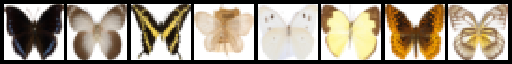

In [32]:
xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("Shape of training batch Xb:", xb.shape)
show_images(xb).resize((8 * 64, 64), resample=Image.NEAREST)

-------------------------------------------------------------------
### ***STEP 3: Definition of the noise scheduler (Scheduler)***

-------------------------------------------------------------------

Our plan for training is to take these input images and add noise to them, then feed the noisy images to the model. And during inference, we will use the model predictions to iteratively remove noise. In `diffusers`, these processes are both handled by the **scheduler**.

The noise schedule determines how much noise is added at different timesteps. Here's how we might create a scheduler using the default settings for 'DDPM' training and sampling (based on the paper ["Denoising Diffusion Probabilistic Models"](https://arxiv.org/abs/2006.11239)):

#### The 'cosine' schedule, which may be better for small image sizes:

In [33]:
print("--- Step 3: Scheduler Setup ---")
# We will use an improved "cosine" scheduler, which is better for small image resolutions
noise_scheduler_A = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

--- Step 3: Scheduler Setup ---


The DDPM paper describes a corruption process that adds a small amount of noise for every 'timestep'. Given $x_{t-1}$ for some timestep, we can get the next (slightly more noisy) version $x_t$ with:<br><br>

$q(\mathbf{x}_t \vert \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t\mathbf{I}) \quad
q(\mathbf{x}_{1:T} \vert \mathbf{x}_0) = \prod^T_{t=1} q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$<br><br>


That is, we take $x_{t-1}$, scale it by $\sqrt{1 - \beta_t}$ and add noise scaled by $\beta_t$. This $\beta$ is defined for every t according to some schedule, and determines how much noise is added per timestep. Now, we don't necessarily want to do this operation 500 times to get $x_{500}$ so we have another formula to get $x_t$ for any t given $x_0$: <br><br>

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, {(1 - \bar{\alpha}_t)} \mathbf{I})
\end{aligned}$ where $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$ and $\alpha_i = 1-\beta_i$<br><br>

The maths notation always looks scary! Luckily the scheduler handles all that for us. We can plot $\sqrt{\bar{\alpha}_t}$ (labelled as `sqrt_alpha_prod`) and $\sqrt{(1 - \bar{\alpha}_t)}$ (labelled as `sqrt_one_minus_alpha_prod`) to view how the input (x) and the noise are scaled and mixed across different timesteps:

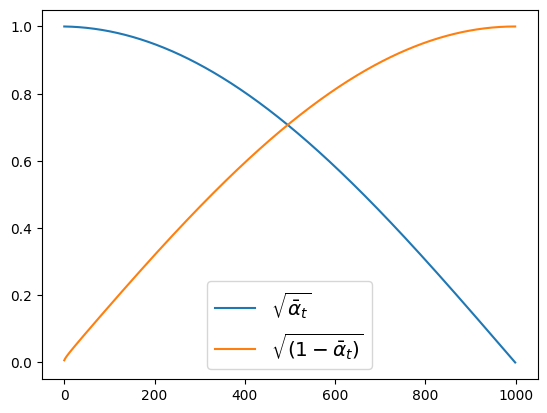

In [34]:
plt.plot(noise_scheduler_A.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler_A.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");

#### One with too little noise added:

In [35]:
noise_scheduler_B = DDPMScheduler(
    num_train_timesteps=1000, 
    beta_start=0.001, 
    beta_end=0.004
)

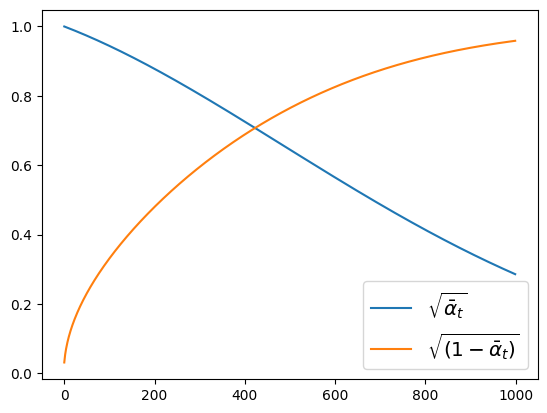

In [36]:
plt.plot(noise_scheduler_B.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler_B.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");

Whichever scheduler you've chosen, we can now use it to add noise in different amounts using the noise_scheduler.add_noise function like so:

Noisy X shape torch.Size([8, 3, 32, 32])


/tmp/ipykernel_58/1866057003.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


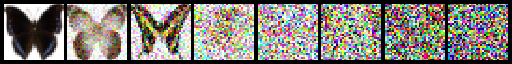

In [37]:
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler_A.add_noise(xb, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)
show_images(noisy_xb).resize((8 * 64, 64), resample=Image.NEAREST)

Again, explore the effect of using different noise schedules and parameters here. This **[video](https://www.youtube.com/watch?v=fbLgFrlTnGU)** does a great job explaining some of the maths above in more detail, and is a great introduction to some of these concepts.

---------------------------------------------------
### ***STEP 4: Model Definition (UNet2DModel)***

---------------------------------------------------

Now we come to the core component: the model itself.

Most diffusion models use architectures that are some variant of a **[U-net](https://arxiv.org/abs/1505.04597)** and that's what we'll use here.

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/unet-model.png)

In a nutshell:
- the model has the input image go through several blocks of ResNet layers, each of which halves the image size by 2
- then through the same number of blocks that upsample it again.
- there are skip connections linking the features on the downsample path to the corresponding layers in the upsample path.

A key feature of this model is that it predicts images of the same size as the input, which is exactly what we need here.

Diffusers provides us a handy `UNet2DModel` class which creates the desired architecture in PyTorch.

Let's create a U-net for our desired image size. 
Note that `down_block_types` correspond to the downsampling blocks (green on the diagram above), and `up_block_types` are the upsampling blocks (red on the diagram):

In [38]:
model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",  # Samopozornost (Self-Attention) na nižších rozlišeních
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

***UNet2DModel requires two elements as input:***
1. Noisy image (assuming batch_size=1, 3 channels, resolution 32x32)
2. Timestep 'timestep' (scalar value / tensor of dimension 1)

In [39]:
dummy_image = torch.randn(1, 3, image_size, image_size).to(device)
dummy_timestep = torch.tensor([500]).long().to(device)

***Graph generation***<br>
We use depth=3 so that the graph is not extremely huge, but shows the main blocks (ResNet, Attention)

In [40]:
model_graph = draw_graph(
    model, 
    input_data=[dummy_image, dummy_timestep],
    expand_nested=True,
    depth=3, 
    device=device
)

--- Step 4a: Visualization of UNet architecture ---


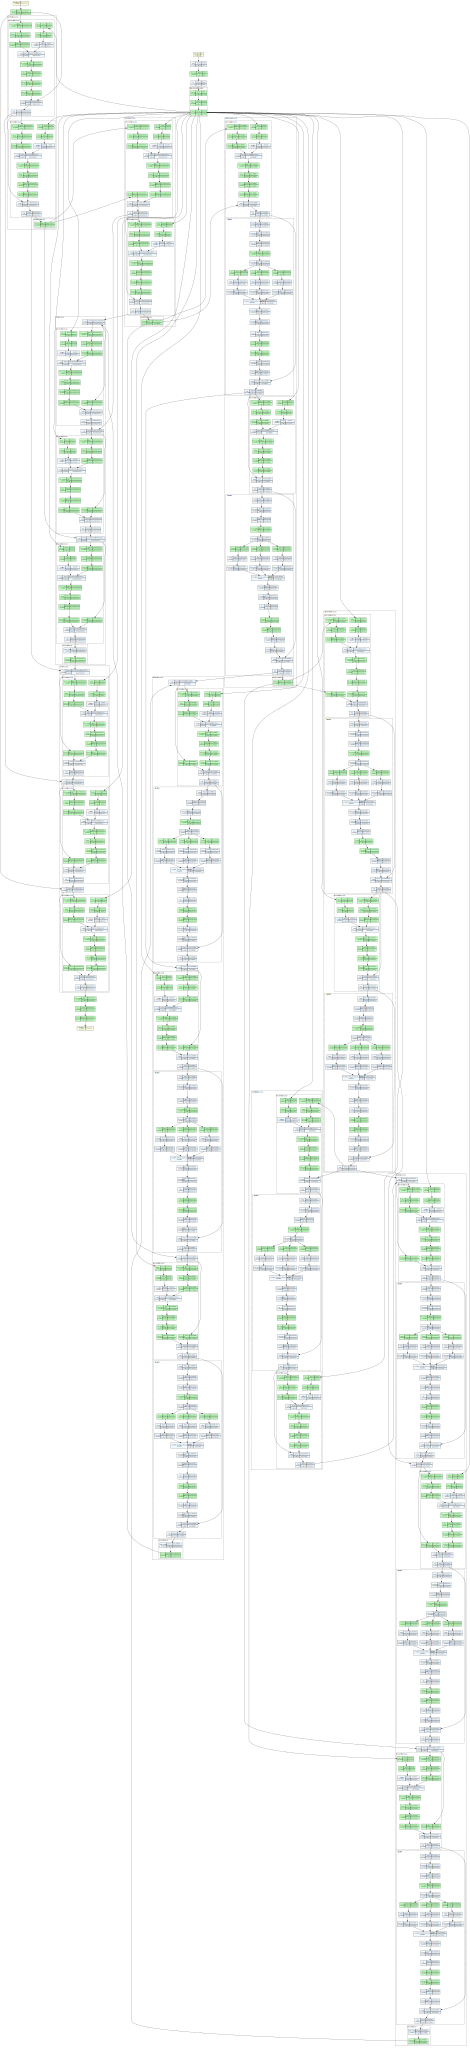

In [41]:
print("--- Step 4a: Visualization of UNet architecture ---")
# View the diagram directly in your notebook
model_graph.visual_graph

In [42]:
print("--- Step 4b: Initialize the UNet model ---")
model.to(device)

--- Step 4b: Initialize the UNet model ---


UNet2DModel(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

---------------------------------------------------------
### ***STEP 5: Create a Training Loop***

---------------------------------------------------------

Below is a typical optimization loop in PyTorch, where we run through the data batch by batch and update the parameters of our model each step using an optimizer - in this case the *AdamW optimizer* with a *learning rate of 0.0004*.

For each batch of data, we

- Sample some random timesteps
- Noise the data accordingly
- Feed the noisy data through the model
- Compare the model predictions with the target (i.e. the noise in this case) using mean squared error as our loss function
- Update the model parameters via loss.backward() and optimizer.step()

During this process we also log the losses over time for later plotting.

NB: This code takes nearly 10 minutes to run - feel free to skip these two cells and use the pretrained model if you are in a hurry. Alternatively, you can explore how reducing the number of channels in each layer via the model definition above can speed things up.

The [official diffusers training example](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/training_example.ipynb) trains a larger model on this dataset at higher resolution, and is a good reference for what a less minimal training loop looks like:

#### Set the noise scheduler and optimizer

In [44]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, 
    beta_schedule="squaredcos_cap_v2"
)

optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
losses = []


In [45]:
print("--- Step 5: Starting training ---")

# We train for 30 epochs (about 5-10 minutes on a regular GPU)
for epoch in range(30):
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["images"].to(device)
        # Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        # Update the model parameters with the optimizer
        optimizer.step()
        optimizer.zero_grad()

    if (epoch + 1) % 5 == 0:
        loss_last_epoch = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
        print(f"Epoch:{epoch+1}, loss: {loss_last_epoch}")

--- Step 5: Starting training ---


/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch:5, loss: 0.1611715368926525
Epoch:10, loss: 0.11059250636026263
Epoch:15, loss: 0.09271901892498136
Epoch:20, loss: 0.08445737650617957
Epoch:25, loss: 0.08175726095214486
Epoch:30, loss: 0.07831970416009426


Plotting the loss, we see that the model rapidly improves initially and then continues to get better at a slower rate (which is more obvious if we use a log scale as shown on the right):

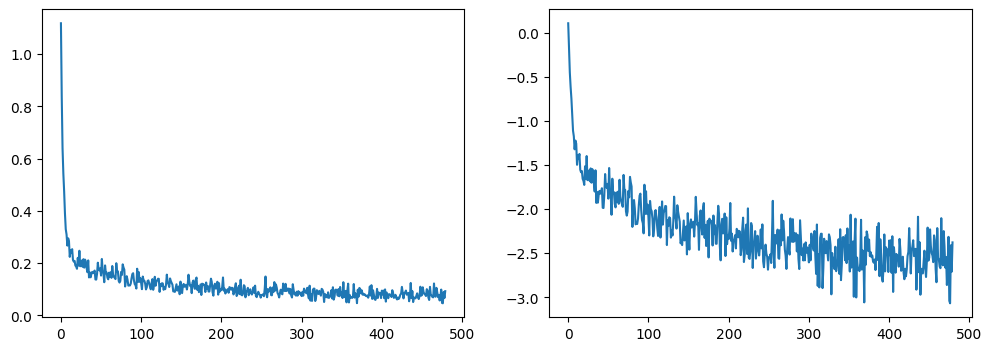

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

-----------------------------------------------------------
### ***STEP 6: Image Generation (Inference / Sampling)***
-----------------------------------------------------------